In [ ]:
!pip install ./cacheflow-0.1.0-py3-none-any.whl
!pip install -U pandas matplotlib seaborn

Processing ./cacheflow-0.1.0-py3-none-any.whl
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 126.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, 

In [ ]:
import os
import time
from datetime import datetime

import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from huggingface_hub import snapshot_download
from transformers import AutoTokenizer

from cacheflow import initialize_model

In [ ]:
model_name = "ibm-granite/granite-3.1-3b-a800m-instruct"
model_path = "./weights/granite/"

In [ ]:
prompts = [
  "Question: What is the capital of Bangladesh?\nAnswer:",
  "Question: Summarize the benefits of caching in 1 sentence.\nAnswer:",
  "Question: List 3 colors.\nAnswer:",
]

In [ ]:
gen_kwargs = {
  "max_new_tokens": 64,
  "min_new_tokens": 16,
  "temperature": 0.5,
  "top_k": 10,
  "repetition_penalty": 1.15,
  "block_special_tokens": True,
  "return_raw": True,
}

In [ ]:
cache_sizes = [2, 4, 8]
staging_slots_list = [1, 1, 2, 4]
runs_per_setting = 3
pin_staging = True

In [ ]:
def get_cache_stats(model):
  layer0 = model.model.model.layers[0].block_sparse_moe
  input_stats = layer0.input_linear.cache.stats()
  output_stats = layer0.output_linear.cache.stats()
  return {
    "input_hits": input_stats["hits"],
    "input_misses": input_stats["misses"],
    "input_evictions": input_stats["evictions"],
    "input_puts": input_stats["puts"],
    "input_skipped_cache": input_stats["skipped_cache"],
    "input_hit_rate": input_stats["hit_rate"],
    "input_miss_rate": input_stats["miss_rate"],
    "input_eviction_rate": input_stats["eviction_rate"],
    "output_hits": output_stats["hits"],
    "output_misses": output_stats["misses"],
    "output_evictions": output_stats["evictions"],
    "output_puts": output_stats["puts"],
    "output_skipped_cache": output_stats["skipped_cache"],
    "output_hit_rate": output_stats["hit_rate"],
    "output_miss_rate": output_stats["miss_rate"],
    "output_eviction_rate": output_stats["eviction_rate"],
  }

In [ ]:
def generate_with_timing(model, tokenizer, prompt, **kwargs):
  if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    start_event.record()
  start_wall = time.perf_counter()

  result = model.generate_text(
    tokenizer=tokenizer,
    prompt=prompt,
    eos_token_id=model.config.eos_token_id,
    **kwargs,
  )

  if torch.cuda.is_available():
    end_event.record()
    torch.cuda.synchronize()
    elapsed_ms = start_event.elapsed_time(end_event)
  else:
    elapsed_ms = (time.perf_counter() - start_wall) * 1000.0

  wall_ms = (time.perf_counter() - start_wall) * 1000.0
  token_count = len(result["token_ids"]) if "token_ids" in result else 0

  if torch.cuda.is_available():
    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    curr_mem_mb = torch.cuda.memory_allocated() / (1024 ** 2)
    reserved_mb = torch.cuda.memory_reserved() / (1024 ** 2)
  else:
    peak_mem_mb = 0.0
    curr_mem_mb = 0.0
    reserved_mb = 0.0

  return {
    "result": result,
    "elapsed_ms": elapsed_ms,
    "wall_ms": wall_ms,
    "token_count": token_count,
    "peak_mem_mb": peak_mem_mb,
    "curr_mem_mb": curr_mem_mb,
    "reserved_mb": reserved_mb,
  }

In [ ]:
def compute_metrics(elapsed_ms, token_count):
  if token_count <= 0:
    return {
      "ms_per_token": float("nan"),
      "tokens_per_sec": float("nan"),
      "tokens_per_min": float("nan"),
    }
  ms_per_token = elapsed_ms / token_count
  tokens_per_sec = 1000.0 / ms_per_token
  tokens_per_min = tokens_per_sec * 60.0
  return {
    "ms_per_token": ms_per_token,
    "tokens_per_sec": tokens_per_sec,
    "tokens_per_min": tokens_per_min,
  }

In [ ]:
from huggingface_hub import snapshot_download
snapshot_download(model_name, local_dir=model_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

'/content/weights/granite'

In [ ]:
import os
import json
from safetensors import safe_open
from safetensors.torch import save_file


def separate_safetensors_smart(input_path, output_directory):
    # 1. Create the output directory
    os.makedirs(output_directory, exist_ok=True)

    new_weight_map = {}
    total_size = 0
    files_to_process = []
    input_dir = os.path.dirname(input_path)

    # 2. Figure out if the input is a single file or an index.json
    if input_path.endswith(".json"):
        print(f"Detected index JSON. Reading {input_path}...")
        with open(input_path, "r") as f:
            index_data = json.load(f)

        # Look at the old weight map to find out what shard files exist
        old_weight_map = index_data.get("weight_map", {})

        # Get a list of unique shard files (e.g. model-00001-of-00003.safetensors)
        unique_shards = set(old_weight_map.values())

        # Build the full paths to those shards
        for shard in unique_shards:
            shard_path = os.path.join(input_dir, shard) if input_dir else shard
            files_to_process.append(shard_path)

        print(f"Found {len(files_to_process)} shard file(s) to unpack.")

    elif input_path.endswith(".safetensors"):
        print(f"Detected single safetensors file: {input_path}")
        files_to_process = [input_path]
    else:
        raise ValueError("Input file must be a .safetensors or .index.json file")

    # 3. Process every file we found
    tensor_count = 0

    for file_path in files_to_process:
        print(f"\nOpening {os.path.basename(file_path)}...")

        # Open lazily
        with safe_open(file_path, framework="pt", device="cpu") as f:
            keys = f.keys()
            for key in keys:
                tensor_count += 1

                # Extract only this specific layer into RAM
                tensor = f.get_tensor(key)

                # Create exact filename for this layer
                filename = f"{key}.safetensors"
                output_path = os.path.join(output_directory, filename)

                # Save it to the new folder
                save_file({key: tensor}, output_path)

                # Track size and map it for the new index
                file_size = os.path.getsize(output_path)
                total_size += file_size
                new_weight_map[key] = filename

                print(f"  Saved: {filename}")

    # 4. Generate the NEW model.safetensors.index.json
    print("\nAll layers separated. Generating new model.safetensors.index.json...")

    new_index_data = {
        "metadata": {"total_size": total_size},
        "weight_map": new_weight_map,
    }

    index_out_path = os.path.join(output_directory, "model.safetensors")

    with open(index_out_path, "w") as index_file:
        json.dump(new_index_data, index_file, indent=2)

    print(f"\n--- SUCCESS ---")
    print(f"Total separate tensors saved: {tensor_count}")
    print(f"Total model size: {total_size / (1024**3):.2f} GB")
    print(f"New index saved to: {index_out_path}")


# ==========================================
# CONFIGURATION - CHANGE THESE PATHS
# ==========================================

# Scenario A: Point this to a single large file
# INPUT_PATH = "model.safetensors"

# Scenario B: Point this to an existing index file
INPUT_PATH = "./weights/granite/model.safetensors.index.json"

# The folder where all the tiny files and the new index will be created
OUTPUT_DIR = "./weights/granite/"

separate_safetensors_smart(INPUT_PATH, OUTPUT_DIR)


Detected index JSON. Reading ./weights/granite/model.safetensors.index.json...
Found 2 shard file(s) to unpack.

Opening model-00002-of-00002.safetensors...
  Saved: model.layers.24.block_sparse_moe.input_linear.weight.safetensors
  Saved: model.layers.24.block_sparse_moe.output_linear.weight.safetensors
  Saved: model.layers.24.block_sparse_moe.router.layer.weight.safetensors
  Saved: model.layers.24.input_layernorm.weight.safetensors
  Saved: model.layers.24.post_attention_layernorm.weight.safetensors
  Saved: model.layers.25.block_sparse_moe.input_linear.weight.safetensors
  Saved: model.layers.25.block_sparse_moe.output_linear.weight.safetensors
  Saved: model.layers.25.block_sparse_moe.router.layer.weight.safetensors
  Saved: model.layers.25.input_layernorm.weight.safetensors
  Saved: model.layers.25.post_attention_layernorm.weight.safetensors
  Saved: model.layers.25.self_attn.k_proj.weight.safetensors
  Saved: model.layers.25.self_attn.o_proj.weight.safetensors
  Saved: model.la

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_path)

In [13]:
results = []
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = os.path.join("results", f"bench_{timestamp}")
os.makedirs(results_dir, exist_ok=True)

valid_grid = []
for cache_size in cache_sizes:
  if cache_size <= 0:
    continue
  for staging_slots in staging_slots_list:
    if staging_slots <= cache_size:
      valid_grid.append((cache_size, staging_slots))

for cache_size, staging_slots in valid_grid:
  print(f"Running cache_size={cache_size}, staging_slots={staging_slots}")
  model = initialize_model(
    model_path,
    cache_size=cache_size,
    staging_slots=staging_slots,
    pin_staging=pin_staging,
  )

  if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = model.config.pad_token_id

  # Warmup
  _ = model.generate_text(
    tokenizer=tokenizer,
    prompt=prompts[0],
    eos_token_id=model.config.eos_token_id,
    max_new_tokens=8,
    min_new_tokens=4,
    temperature=0.7,
    top_k=10,
    repetition_penalty=1.1,
    block_special_tokens=True,
    return_raw=False,
  )

  for run_idx in range(runs_per_setting):
    for prompt_idx, prompt in enumerate(prompts):
      timing = generate_with_timing(model, tokenizer, prompt, **gen_kwargs)
      metrics = compute_metrics(timing["elapsed_ms"], timing["token_count"])
      cache_stats = get_cache_stats(model)

      results.append(
        {
          "cache_size": cache_size,
          "staging_slots": staging_slots,
          "run_idx": run_idx,
          "prompt_idx": prompt_idx,
          "elapsed_ms": timing["elapsed_ms"],
          "wall_ms": timing["wall_ms"],
          "token_count": timing["token_count"],
          "ms_per_token": metrics["ms_per_token"],
          "tokens_per_sec": metrics["tokens_per_sec"],
          "tokens_per_min": metrics["tokens_per_min"],
          "peak_mem_mb": timing["peak_mem_mb"],
          "curr_mem_mb": timing["curr_mem_mb"],
          "reserved_mb": timing["reserved_mb"],
          **cache_stats,
        }
      )

  del model
  if torch.cuda.is_available():
    torch.cuda.empty_cache()

Running cache_size=2, staging_slots=1
Running cache_size=2, staging_slots=1
Running cache_size=2, staging_slots=2
Running cache_size=4, staging_slots=1
Running cache_size=4, staging_slots=1
Running cache_size=4, staging_slots=2
Running cache_size=4, staging_slots=4
Running cache_size=8, staging_slots=1
Running cache_size=8, staging_slots=1
Running cache_size=8, staging_slots=2
Running cache_size=8, staging_slots=4


In [14]:
df = pd.DataFrame(results)
raw_csv = os.path.join(results_dir, "bench_raw.csv")
df.to_csv(raw_csv, index=False)

group_cols = ["cache_size", "staging_slots"]
summary = df.groupby(group_cols).agg(
  {
    "ms_per_token": ["mean", "std"],
    "tokens_per_min": ["mean", "std"],
    "peak_mem_mb": ["mean", "std"],
    "input_hit_rate": ["mean", "std"],
    "output_hit_rate": ["mean", "std"],
    "input_miss_rate": ["mean", "std"],
    "output_miss_rate": ["mean", "std"],
    "input_skipped_cache": ["mean", "std"],
    "output_skipped_cache": ["mean", "std"],
  }
)
summary.columns = ["_".join(col) for col in summary.columns]
summary = summary.reset_index()
summary_csv = os.path.join(results_dir, "bench_summary.csv")
summary.to_csv(summary_csv, index=False)

print(f"Saved raw results: {raw_csv}")
print(f"Saved summary: {summary_csv}")

Saved raw results: results/bench_20260429_104440/bench_raw.csv
Saved summary: results/bench_20260429_104440/bench_summary.csv


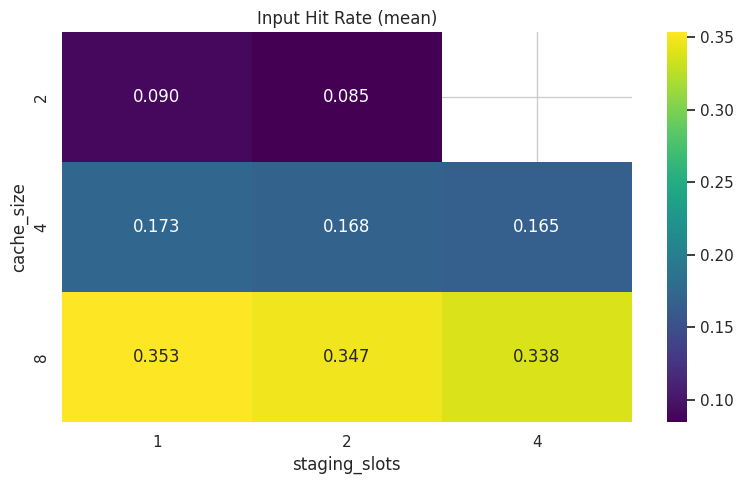

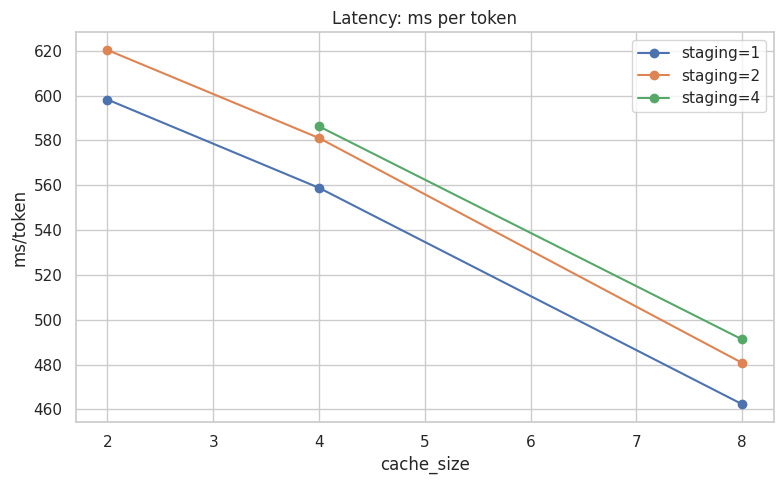

/tmp/ipykernel_735/2319859621.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


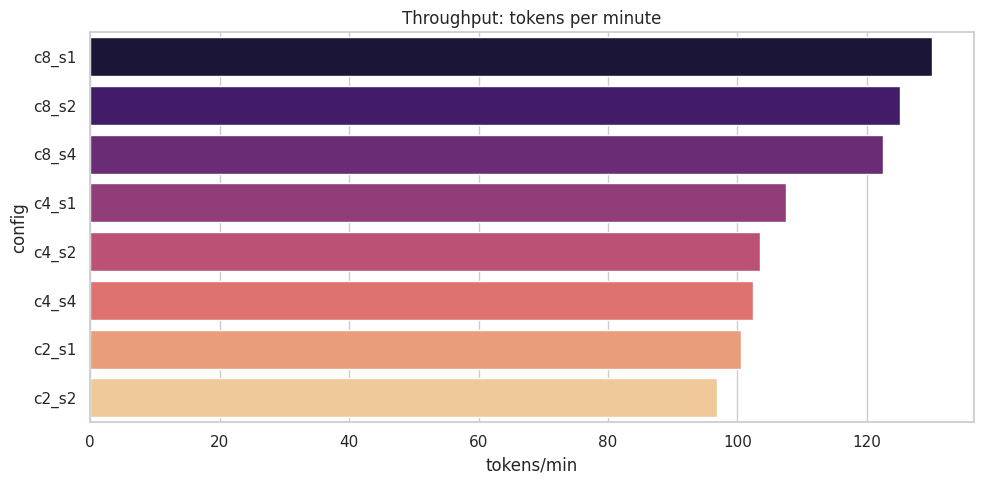

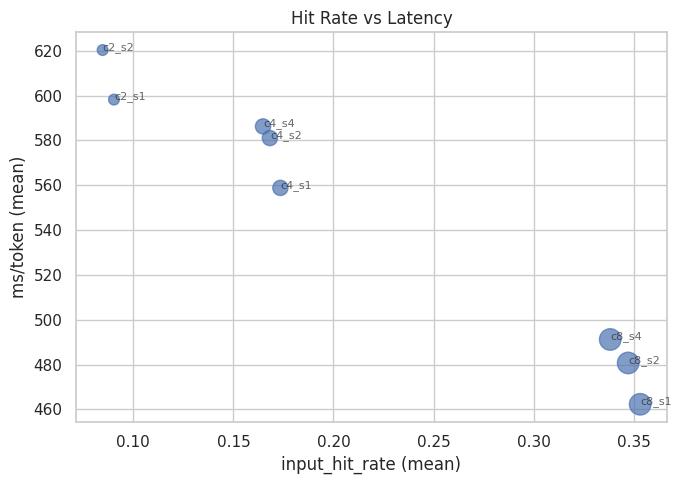

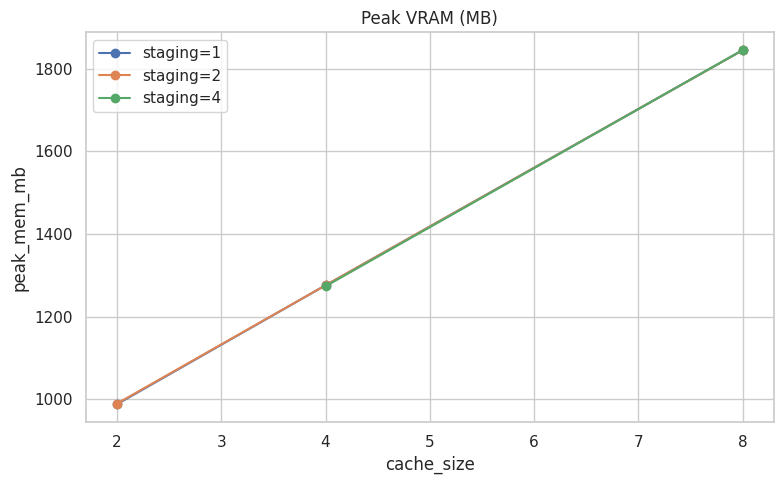

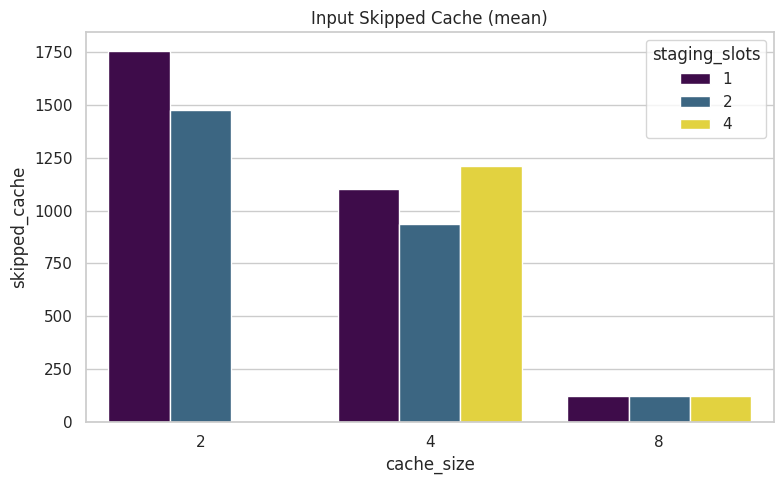

In [15]:
sns.set_theme(style="whitegrid")

# Heatmap: input_hit_rate
heatmap_data = summary.pivot(
  index="cache_size",
  columns="staging_slots",
  values="input_hit_rate_mean",
)
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
plt.title("Input Hit Rate (mean)")
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "heatmap_input_hit_rate.png"))
plt.show()

# Line: ms_per_token vs cache_size
plt.figure(figsize=(8, 5))
for staging_slots in sorted(summary["staging_slots"].unique()):
  subset = summary[summary["staging_slots"] == staging_slots]
  plt.plot(
    subset["cache_size"],
    subset["ms_per_token_mean"],
    marker="o",
    label=f"staging={staging_slots}",
  )
plt.title("Latency: ms per token")
plt.xlabel("cache_size")
plt.ylabel("ms/token")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "line_ms_per_token.png"))
plt.show()

# Bar: tokens/min by config
plt.figure(figsize=(10, 5))
summary_sorted = summary.sort_values("tokens_per_min_mean", ascending=False)
sns.barplot(
  data=summary_sorted,
  x="tokens_per_min_mean",
  y=summary_sorted.apply(
    lambda r: f"c{int(r['cache_size'])}_s{int(r['staging_slots'])}", axis=1
  ),
  palette="magma",
)
plt.title("Throughput: tokens per minute")
plt.xlabel("tokens/min")
plt.ylabel("config")
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "bar_tokens_per_min.png"))
plt.show()

# Scatter: hit_rate vs ms/token (size = cache_size)
plt.figure(figsize=(7, 5))
plt.scatter(
  summary["input_hit_rate_mean"],
  summary["ms_per_token_mean"],
  s=summary["cache_size"] * 30,
  alpha=0.7,
)
for _, row in summary.iterrows():
  plt.annotate(
    f"c{int(row['cache_size'])}_s{int(row['staging_slots'])}",
    (row["input_hit_rate_mean"], row["ms_per_token_mean"]),
    fontsize=8,
    alpha=0.7,
  )
plt.title("Hit Rate vs Latency")
plt.xlabel("input_hit_rate (mean)")
plt.ylabel("ms/token (mean)")
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "scatter_hit_rate_vs_latency.png"))
plt.show()

# Memory: peak VRAM vs cache_size
plt.figure(figsize=(8, 5))
for staging_slots in sorted(summary["staging_slots"].unique()):
  subset = summary[summary["staging_slots"] == staging_slots]
  plt.plot(
    subset["cache_size"],
    subset["peak_mem_mb_mean"],
    marker="o",
    label=f"staging={staging_slots}",
  )
plt.title("Peak VRAM (MB)")
plt.xlabel("cache_size")
plt.ylabel("peak_mem_mb")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "line_peak_vram.png"))
plt.show()

# Skipped cache: input_skipped_cache mean
plt.figure(figsize=(8, 5))
sns.barplot(
  data=summary,
  x="cache_size",
  y="input_skipped_cache_mean",
  hue="staging_slots",
  palette="viridis",
)
plt.title("Input Skipped Cache (mean)")
plt.xlabel("cache_size")
plt.ylabel("skipped_cache")
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "bar_input_skipped_cache.png"))
plt.show()